In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [2]:
# 0.5 mm diameter?
r1 = 0.0005 / 2 # m
A1 = np.pi * r1 ** 2 # m^2
L345 = 0.345 # m
Temp345 = np.array([28, 30, 41, 48, 57, 70, 77, 90, 115]) # Celsius
u_Temp345 = 2
eigen_f345 = np.array([350.4, 349.9, 349.2, 348.2, 347.2, 346.4, 344.5, 342.7 ,337.7]) # Hz
u_f345 = 1


# 0.1 mm diameter voor 22.5, 49.8 
r2 = 0.00025/2 # m
A2 = np.pi * r2 ** 2 # m^2
L225 = 0.225 # m
Temp225 = np.array([27, 45, 60, 81, 91, 100, 129, 159, 174, 205, 236]) # Celsius
u_Temp225 = 2
eigen_f225 = np.array([854.49, 842.28, 830.07, 817.87, 805.66, 799.56, 775.14, 769.04, 750.73, 720.21, 677.49]) # Hz
u_f225 = 1 # Vanaf 100 graden ...ehhh

L498 = 0.498 # m
Temp498 = np.array([27, 45, 64, 81, 115, 135, 155, 202, 263, 350, 450]) # Celsius
u_Temp498 = 3 # Onzekerheid 3 graden
eigen_f498 = np.array([280.76, 268.55, 256.34, 244.14, 225.83, 207.51, 195.31, 177, 152.58, 109.86, 30.51]) # Hz
u_f498 = 1 # Vanaf 100 graden ...ehhh

In [3]:
def frequentie(mu, T, L, n, dL, dT):
    v = np.sqrt((T + dT) / mu)
    return n * v / (2 * (L + dL))

lijn = np.linspace(0.1, 1, int(1e4))
n = 1

di = 7900 # Dichtheid van staal (kg/m^3)
u_di = 200 # kg/m^3
# r = 0.0005/2 #m 
# u_r = 0.0001 #m
# opp = np.pi*r**2
# mu = di * opp #kg/m

popt, pcov = curve_fit(frequentie, Temp345, eigen_f345)
print(popt)

[1.78283246e+02 1.02852543e-02 5.22669230e+00 1.02852544e-02
 1.78283246e+02]


In [4]:
alpha_V = 32.4 * (10**-6)  # Volumetric thermal expansion coefficient of carbon steel
alpha_L = 10.8 * (10**-6)  # Linear thermal expansion coefficient of carbon steel

YM = 2.0 * (10**11) #Young's modulus of carbon steel (Pa)

C:\Users\Alejandro\AppData\Local\Temp\ipykernel_30932\140121285.py:2: RuntimeWarning: invalid value encountered in sqrt
  v = np.sqrt((T + dT) / mu)


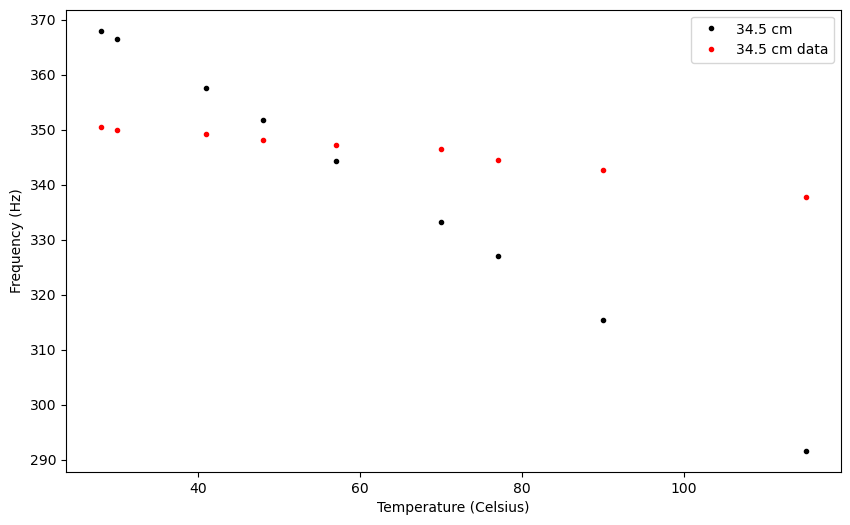

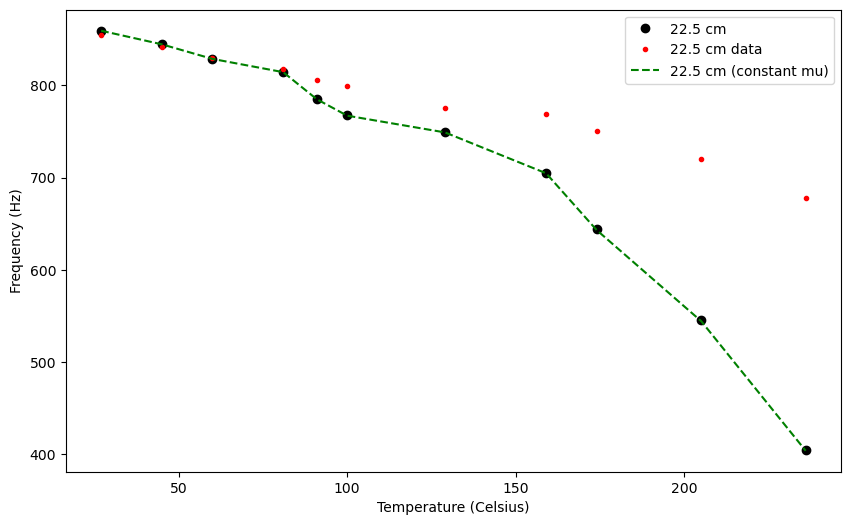

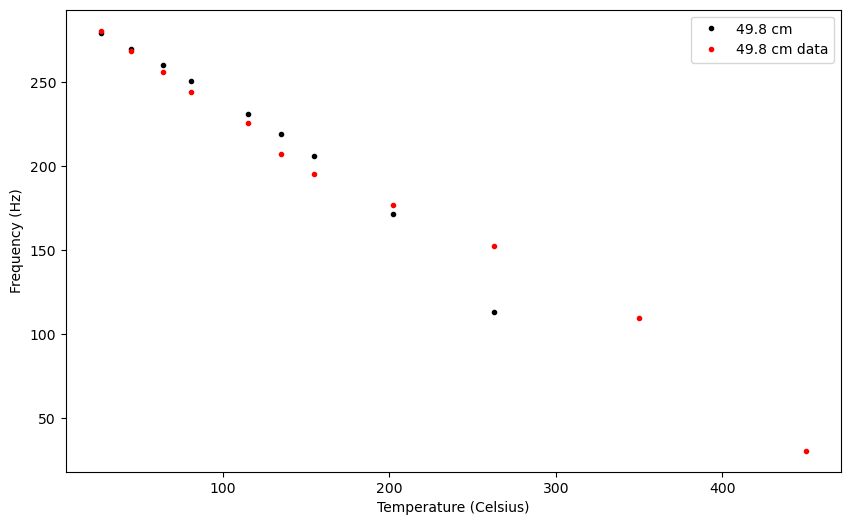

In [ ]:
dTemp345 = np.array([])
dTemp225 = np.array([])
dTemp498 = np.array([])

for i in range(1, len(Temp345)):
    dTemp345 = np.append(dTemp345, Temp345[i] - Temp345[0])

for i in range(1, len(Temp225)):
    dTemp225 = np.append(dTemp225, Temp225[i] - Temp225[0])
    
for i in range(1, len(Temp498)):
    dTemp498 = np.append(dTemp498, Temp498[i] - Temp498[0])

def new_mu(dtemp, V, r, aL, aV, di, A):
    new_mu = np.zeros(len(dtemp) + 1)
    new_mu[0] = di * A
    dr = r * dtemp * aL
    new_r = r + dr
    new_opp = np.pi * new_r ** 2
    V_change = aV * dtemp * V
    New_V = V_change + V
    New_di = (di * V) / New_V
    new_mu[1:] = New_di * new_opp
    L = New_V / new_opp
    dL = np.zeros(len(dtemp) + 1)
    dL[0] = 0
    dL[1:] = L - V / new_opp
    dT = np.zeros(len(dtemp) + 1)
    dT[0] = 0
    dT[1:] = - YM * aL * dtemp * A

    return new_mu, dL, dT

tens1 = 100 #N
tens2 = 58 #N
tens3 = 30 #N

aa = np.zeros(len(dTemp225)+1)
aa[0:] = di * A2

test1 = frequentie( 
    # aa,
    new_mu(dTemp345, L345 * A1, r1, alpha_L, alpha_V, di, A1)[0],
    tens1, L345, n, 
    new_mu(dTemp345, L345 * A1, r1, alpha_L, alpha_V, di, A1)[1], 
    new_mu(dTemp345, L345 * A1, r1, alpha_L, alpha_V, di, A1)[2])

test2 = frequentie( 
    # aa,
    new_mu(dTemp498, L225 * A2, r2, alpha_L, alpha_V, di, A2)[0],
    tens2, L225, n, 
    new_mu(dTemp498, L225 * A2, r2, alpha_L, alpha_V, di, A2)[1], 
    new_mu(dTemp498, L225 * A2, r2, alpha_L, alpha_V, di, A2)[2])

test25 = frequentie( 
    aa,
    # new_mu(dTemp498, L225 * A2, r2, alpha_L, alpha_V, di, A2)[0],
    tens2, L225, n, 
    new_mu(dTemp498, L225 * A2, r2, alpha_L, alpha_V, di, A2)[1], 
    new_mu(dTemp498, L225 * A2, r2, alpha_L, alpha_V, di, A2)[2])

test3 = frequentie( 
    # aa,
    new_mu(dTemp498, L498 * A2, r2, alpha_L, alpha_V, di, A2)[0],
    tens3, L498, n, 
    new_mu(dTemp498, L498 * A2, r2, alpha_L, alpha_V, di, A2)[1], 
    new_mu(dTemp498, L498 * A2, r2, alpha_L, alpha_V, di, A2)[2])

plt.figure(figsize=(10, 6))    
plt.plot(Temp345, test1, "k.", label='34.5 cm')
plt.plot(Temp345, eigen_f345, "r.", label='34.5 cm data')
plt.legend()
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Frequency (Hz)')
plt.savefig('Frequency_vs_Temperature_34_5cm.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 6))    
plt.plot(Temp225, test2, "ko", label='22.5 cm')
plt.plot(Temp225, eigen_f225, "r.", label='22.5 cm data')
plt.plot(Temp225, test25, "g--", label='22.5 cm (constant mu)')
plt.legend()
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Frequency (Hz)')
plt.savefig('Frequency_vs_Temperature_22_5cm.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 6))    
plt.plot(Temp498, test3, "k.", label='49.8 cm')
plt.plot(Temp498, eigen_f498, "r.", label='49.8 cm data')
plt.legend()
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Frequency (Hz)')
plt.tight_layout()
plt.savefig("Frequency_vs_Temperature_49_8cm.png", dpi=300, bbox_inches="tight")
plt.show()

